# Does a correct handover really reduce source load?

This notebook diagnoses one concrete scenario: `high_load_inner_asymmetric`.

We compare neutral control with several center-gNB1 to right-gNB2 eMBB biases. For every action we inspect:

- executed handovers;
- persistent PRB demand carried by attached UEs;
- useful allocated PRBs and physical utilization;
- queue backlog;
- source and target behavior for 20 additional scheduler samples.

The purpose is not to assume that a handover reduces load. It is to measure when and why it does or does not.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'global_ppo_3gnb_env.py').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from global_ppo_3gnb_env import GlobalPPO3GNBEnv
from upper_agent_training_scenarios import CENTER_GAP_GNB_CONFIGS

SLICE = 'eMBB'
GNB_NAMES = ['Left gNB0', 'Center gNB1', 'Right gNB2']

## Measurement helpers

`persistent demand` is the scenario's PRB-equivalent demand attached to each gNB. `allocated utilization` is what the scheduler actually used during the latest radio interval.

In [2]:
def make_env():
    return GlobalPPO3GNBEnv(
        seed=2,
        scenario_mode='curriculum',
        training_scenarios='high_load_inner_asymmetric',
        scenario_selection='cycle',
        gnb_configs=CENTER_GAP_GNB_CONFIGS['medium_270m'],
        upper_window_seconds=1.0,
        local_steps_per_global=10,
        radio_substeps=100,
        radio_tick_seconds=0.001,
        pf_averaging_window_s=0.25,
        terminal_reward_only=False,
        safe_admission_enabled=True,
    )


def physical_snapshot(env):
    ues = env.base_env.get_all_ues()
    load_matrix = env._load_matrix()
    return {
        'allocated': load_matrix.sum(axis=1),
        'persistent': np.asarray([
            sum(
                max(int(getattr(ue, 'upper_demand_prbs', 0)), 0)
                for ue in ues
                if ue.connected and int(ue.serving_gnb) == gnb_id
            ) / 100.0
            for gnb_id in range(3)
        ]),
        'queue_kbits': np.asarray([
            sum(
                max(float(getattr(ue, 'queue', 0.0)), 0.0)
                for ue in ues
                if ue.connected and int(ue.serving_gnb) == gnb_id
            ) / 1000.0
            for gnb_id in range(3)
        ]),
        'ue_count': np.asarray([
            sum(ue.connected and int(ue.serving_gnb) == gnb_id for ue in ues)
            for gnb_id in range(3)
        ], dtype=int),
    }


def run_case(label, right_bias, settle_samples=20):
    env = make_env()
    try:
        _, reset_info = env.reset(seed=2)
        before = physical_snapshot(env)
        before['allocated'] = np.asarray(reset_info['gnb_total_load_end'], dtype=float)

        action = np.zeros((3, 2, 3), dtype=np.float32)
        action[1, 1, 0] = float(right_bias)  # center -> right, eMBB
        _, reward, _, _, info = env.step(action.reshape(-1))
        after = physical_snapshot(env)
        after['allocated'] = np.asarray(info['gnb_total_load_end'], dtype=float)
        events = list(env.base_env.get_handover_events())

        # Prevent further handovers while observing scheduler settling.
        env._apply_slice_offsets(np.full((3, 2, 3), 6.0, dtype=float))
        env.base_env.begin_safe_admission_window(
            np.zeros((3, 2, 3), dtype=np.float32), env.slice_types
        )
        env.base_env.begin_radio_measurement_window()

        trace_rows = []
        for sample in range(settle_samples):
            env.base_env.step(0)
            snap = physical_snapshot(env)
            for gnb_id in range(3):
                trace_rows.append({
                    'case': label,
                    'sample': sample + 1,
                    'gNB': GNB_NAMES[gnb_id],
                    'allocated utilization': snap['allocated'][gnb_id],
                    'persistent demand': snap['persistent'][gnb_id],
                    'queue kbits': snap['queue_kbits'][gnb_id],
                })
            if (sample + 1) % env.local_steps_per_global == 0:
                env._calibrate_demand_from_radio_window()
                env.base_env.begin_radio_measurement_window()

        return {
            'label': label,
            'bias': right_bias,
            'reward': float(reward),
            'handovers': int(info['handover_count']),
            'routes': [(int(e['ue_id']), int(e['from_gnb']), int(e['to_gnb'])) for e in events],
            'before': before,
            'after': after,
            'settled_mean': (
                pd.DataFrame(trace_rows)
                .groupby('gNB')['allocated utilization'].mean()
                .reindex(GNB_NAMES).to_numpy()
            ),
            'reward_load': float(info['reward_load_improvement']),
            'reward_saturation': float(info['reward_saturation_improvement']),
            'reward_excess': float(info['reward_excess_load_improvement']),
            'effective_target': float(info['gnb_load_target_effective']),
            'safe_admission': info['safe_admission'],
            'trace': pd.DataFrame(trace_rows),
        }
    finally:
        env.close()

## Compare neutral, moderate, and strong rightward actions

In [3]:
cases = [
    run_case('Neutral', 0.0),
    run_case('Moderate right bias', -0.3),
    run_case('Strong right bias', -0.4),
    run_case('Very strong right bias', -0.8),
]

summary_rows = []
for case in cases:
    row = {
        'case': case['label'],
        'bias': case['bias'],
        'handovers': case['handovers'],
        'routes': str(case['routes']),
        'reward': case['reward'],
        'load reward': case['reward_load'],
        'saturation reward': case['reward_saturation'],
        'excess reward': case['reward_excess'],
    }
    for gnb_id in range(3):
        row[f'gNB{gnb_id} allocated before'] = case['before']['allocated'][gnb_id]
        row[f'gNB{gnb_id} allocated after'] = case['after']['allocated'][gnb_id]
        row[f'gNB{gnb_id} persistent after'] = case['after']['persistent'][gnb_id]
        row[f'gNB{gnb_id} settled mean'] = case['settled_mean'][gnb_id]
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
display(summary.style.format({
    column: '{:.3f}'
    for column in summary.columns
    if column not in {'case', 'routes', 'handovers'}
}))
summary

,case,bias,handovers,routes,reward,load reward,saturation reward,excess reward,gNB0 allocated before,gNB0 allocated after,gNB0 persistent after,gNB0 settled mean,gNB1 allocated before,gNB1 allocated after,gNB1 persistent after,gNB1 settled mean,gNB2 allocated before,gNB2 allocated after,gNB2 persistent after,gNB2 settled mean
0,Neutral,0.000,0,[],0.101,0.029,0.000,0.072,0.528,0.533,0.540,0.537,0.982,0.970,0.900,0.988,0.119,0.119,0.120,0.120
1,Moderate right bias,-0.300,1,"[(1, 1, 2)]",0.493,0.426,0.000,0.068,0.528,0.534,0.540,0.543,0.982,0.970,0.750,0.976,0.119,0.330,0.270,0.483
2,Strong right bias,-0.400,2,"[(1, 1, 2), (5, 1, 2)]",1.447,0.748,0.500,0.200,0.528,0.534,0.540,0.540,0.982,0.947,0.600,0.745,0.119,0.627,0.420,0.763
3,Very strong right bias,-0.800,3,"[(1, 1, 2), (5, 1, 2), (3, 1, 2)]",2.118,0.895,0.500,0.724,0.528,0.533,0.540,0.540,0.982,0.805,0.450,0.702,0.119,0.730,0.570,0.996


,case,bias,handovers,routes,reward,load reward,saturation reward,excess reward,gNB0 allocated before,gNB0 allocated after,gNB0 persistent after,gNB0 settled mean,gNB1 allocated before,gNB1 allocated after,gNB1 persistent after,gNB1 settled mean,gNB2 allocated before,gNB2 allocated after,gNB2 persistent after,gNB2 settled mean
0,Neutral,0.0,0,[],0.100972,0.029363,0.0,0.071610,0.52778,0.53336,0.54,0.5375,0.98178,0.96968,0.90,0.9880,0.11899,0.11936,0.12,0.1200
1,Moderate right bias,-0.3,1,"[(1, 1, 2)]",0.493211,0.425588,0.0,0.067772,0.52778,0.53370,0.54,0.5425,0.98178,0.97034,0.75,0.9755,0.11899,0.33012,0.27,0.4825
2,Strong right bias,-0.4,2,"[(1, 1, 2), (5, 1, 2)]",1.447230,0.747911,0.5,0.199585,0.52778,0.53364,0.54,0.5405,0.98178,0.94683,0.60,0.7445,0.11899,0.62698,0.42,0.7635
3,Very strong right bias,-0.8,3,"[(1, 1, 2), (5, 1, 2), (3, 1, 2)]",2.117819,0.894630,0.5,0.724256,0.52778,0.53350,0.54,0.5395,0.98178,0.80466,0.45,0.7025,0.11899,0.73021,0.57,0.9960


## One strong action in detail

This table separates the expected demand transfer from actual scheduler allocation.

In [4]:
chosen = next(case for case in cases if case['label'] == 'Strong right bias')
detail_rows = []
for gnb_id, name in enumerate(GNB_NAMES):
    detail_rows.append({
        'gNB': name,
        'UEs before': chosen['before']['ue_count'][gnb_id],
        'UEs after': chosen['after']['ue_count'][gnb_id],
        'persistent demand before (%)': 100 * chosen['before']['persistent'][gnb_id],
        'persistent demand after (%)': 100 * chosen['after']['persistent'][gnb_id],
        'allocated before (%)': 100 * chosen['before']['allocated'][gnb_id],
        'allocated after (%)': 100 * chosen['after']['allocated'][gnb_id],
        '20-sample allocated mean (%)': 100 * chosen['settled_mean'][gnb_id],
        'queue before (kbits)': chosen['before']['queue_kbits'][gnb_id],
        'queue after (kbits)': chosen['after']['queue_kbits'][gnb_id],
    })

detail = pd.DataFrame(detail_rows)
display(detail.style.format({
    column: '{:.1f}' for column in detail.columns
    if column != 'gNB' and not column.startswith('UEs')
}))
print('Executed routes (UE, source, target):', chosen['routes'])
detail

,gNB,UEs before,UEs after,persistent demand before (%),persistent demand after (%),allocated before (%),allocated after (%),20-sample allocated mean (%),queue before (kbits),queue after (kbits)
0,Left gNB0,3,3,54.0,54.0,52.8,53.4,54.0,0.0,0.0
1,Center gNB1,6,4,90.0,60.0,98.2,94.7,74.5,0.0,9.5
2,Right gNB2,1,3,12.0,42.0,11.9,62.7,76.3,0.0,977.2


Executed routes (UE, source, target): [(1, 1, 2), (5, 1, 2)]


,gNB,UEs before,UEs after,persistent demand before (%),persistent demand after (%),allocated before (%),allocated after (%),20-sample allocated mean (%),queue before (kbits),queue after (kbits)
0,Left gNB0,3,3,54.0,54.0,52.778,53.364,54.05,0.0,0.001000
1,Center gNB1,6,4,90.0,60.0,98.178,94.683,74.45,0.0,9.470600
2,Right gNB2,1,3,12.0,42.0,11.899,62.698,76.35,0.0,977.244531


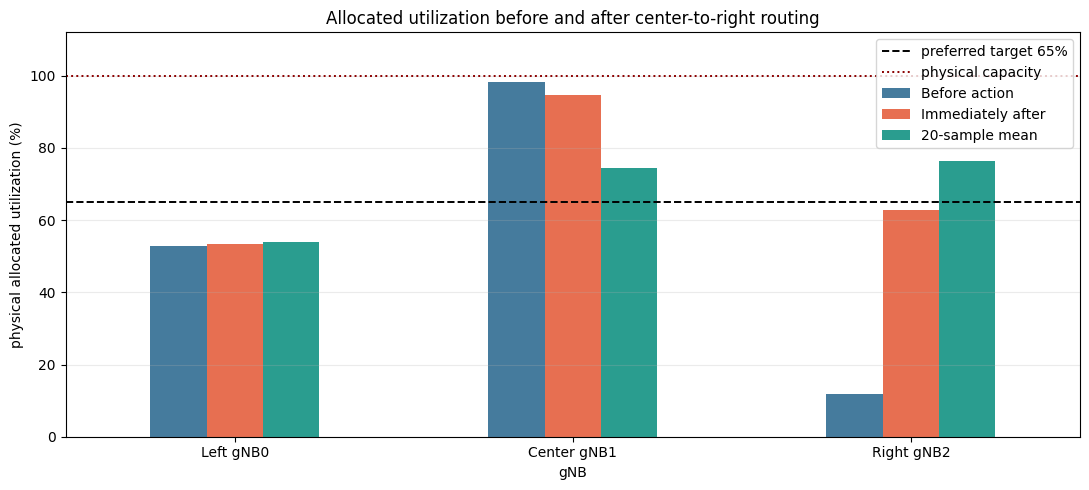

In [5]:
plot_rows = []
for phase, values in [
    ('Before action', chosen['before']['allocated']),
    ('Immediately after', chosen['after']['allocated']),
    ('20-sample mean', chosen['settled_mean']),
]:
    for gnb_id, value in enumerate(values):
        plot_rows.append({'phase': phase, 'gNB': GNB_NAMES[gnb_id], 'utilization': value})

plot_df = pd.DataFrame(plot_rows)
pivot = plot_df.pivot(index='gNB', columns='phase', values='utilization').reindex(GNB_NAMES)
pivot = pivot[['Before action', 'Immediately after', '20-sample mean']]
ax = (100 * pivot).plot(kind='bar', figsize=(11, 5), color=['#457b9d', '#e76f51', '#2a9d8f'])
ax.axhline(65, color='black', linestyle='--', linewidth=1.4, label='preferred target 65%')
ax.axhline(100, color='darkred', linestyle=':', linewidth=1.4, label='physical capacity')
ax.set(title='Allocated utilization before and after center-to-right routing',
       xlabel='gNB', ylabel='physical allocated utilization (%)', ylim=(0, 112))
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Scheduler settling trace

If the source demand genuinely fits below capacity after the handover, its allocated utilization should eventually fall. Persistent saturation or oscillation indicates queue/radio calibration rather than a routing-sign error.

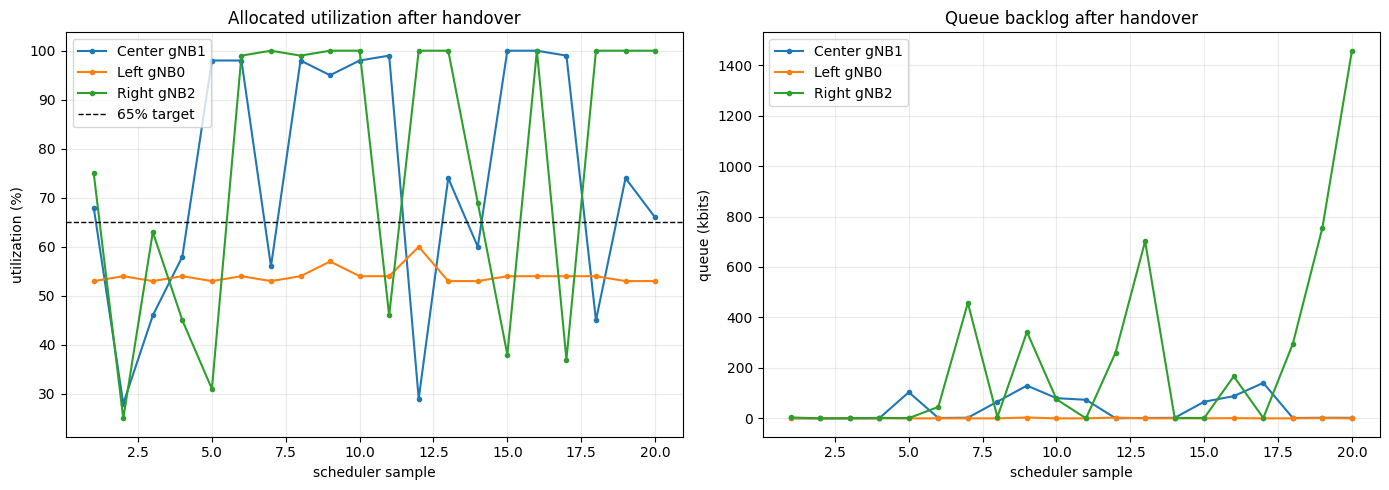

In [6]:
trace = chosen['trace']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for gnb_name, group in trace.groupby('gNB'):
    axes[0].plot(group['sample'], 100 * group['allocated utilization'], marker='o', markersize=3, label=gnb_name)
    axes[1].plot(group['sample'], group['queue kbits'], marker='o', markersize=3, label=gnb_name)
axes[0].axhline(65, color='black', linestyle='--', linewidth=1, label='65% target')
axes[0].set(title='Allocated utilization after handover', xlabel='scheduler sample', ylabel='utilization (%)')
axes[1].set(title='Queue backlog after handover', xlabel='scheduler sample', ylabel='queue (kbits)')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

## Longer calibrated convergence check

Allocated utilization is a scheduler outcome, so a handover can require several upper windows to drain transferred backlog. This check follows the strong action for ten calibrated one-second windows with further handovers disabled.

Allocated utilization after ten calibrated windows:


,utilization (%)
gNB,
Left gNB0,54.9
Center gNB1,60.2
Right gNB2,44.5


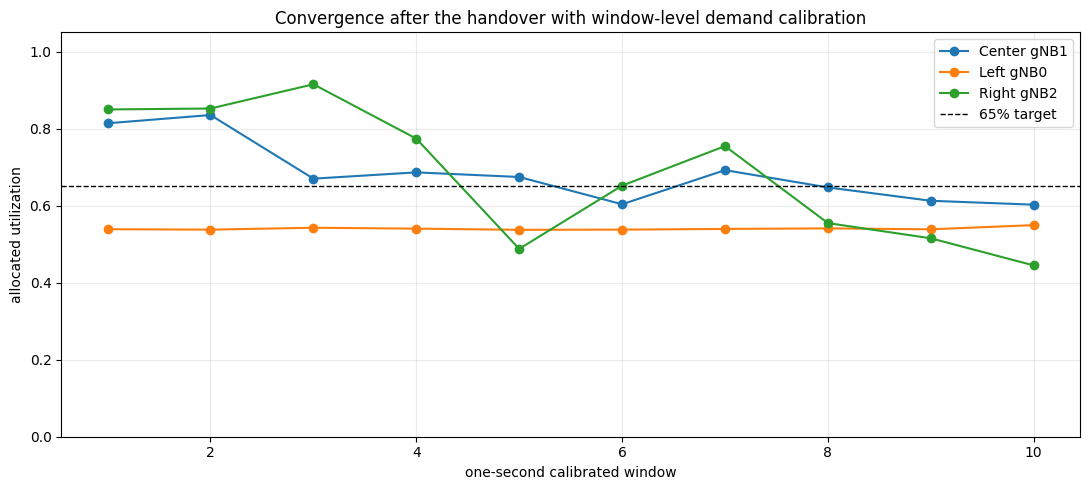

In [7]:
long_env = make_env()
try:
    long_env.reset(seed=2)
    action = np.zeros((3, 2, 3), dtype=np.float32)
    action[1, 1, 0] = -0.4
    long_env.step(action.reshape(-1))
    long_env._apply_slice_offsets(np.full((3, 2, 3), 6.0, dtype=float))
    long_env.base_env.begin_safe_admission_window(
        np.zeros((3, 2, 3), dtype=np.float32), long_env.slice_types
    )

    convergence_rows = []
    for window_idx in range(1, 11):
        long_env.base_env.begin_radio_measurement_window()
        for _ in range(long_env.local_steps_per_global):
            long_env.base_env.step(0)
        average = long_env._window_average_load_matrix().sum(axis=1)
        long_env._calibrate_demand_from_radio_window()
        for gnb_id, value in enumerate(average):
            convergence_rows.append({
                'window': window_idx,
                'gNB': GNB_NAMES[gnb_id],
                'allocated utilization': value,
            })
finally:
    long_env.close()

convergence = pd.DataFrame(convergence_rows)
final_convergence = (
    convergence[convergence['window'] == 10]
    .set_index('gNB')['allocated utilization']
    .reindex(GNB_NAMES)
)
print('Allocated utilization after ten calibrated windows:')
display((100 * final_convergence).to_frame('utilization (%)').style.format('{:.1f}'))

ax = convergence.pivot(index='window', columns='gNB', values='allocated utilization').plot(
    figsize=(11, 5), marker='o'
)
ax.axhline(0.65, color='black', linestyle='--', linewidth=1, label='65% target')
ax.set(title='Convergence after the handover with window-level demand calibration',
       xlabel='one-second calibrated window', ylabel='allocated utilization', ylim=(0, 1.05))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Automatic interpretation

The routing action is physically successful only when the source's allocated utilization falls and the target does not become equally or more congested.

In [8]:
source_before = chosen['before']['allocated'][1]
source_mean = chosen['settled_mean'][1]
target_before = chosen['before']['allocated'][2]
target_mean = chosen['settled_mean'][2]

source_reduced = source_mean < source_before - 0.05
target_safe = target_mean <= chosen['effective_target'] + 0.05

print(f'Source allocated utilization: {source_before:.2f} -> {source_mean:.2f}')
print(f'Target allocated utilization: {target_before:.2f} -> {target_mean:.2f}')
print('Source materially reduced:', source_reduced)
print('Target remained near effective target:', target_safe)

if source_reduced and target_safe:
    print('RESULT: this action produced real physical load balancing.')
else:
    print('RESULT: routing intent was valid, but this scenario did not produce clean physical unloading.')
    print('Inspect persistent-demand calibration, realized MCS, and queue backlog before training on it.')

Source allocated utilization: 0.98 -> 0.74
Target allocated utilization: 0.12 -> 0.76
Source materially reduced: True
Target remained near effective target: False
RESULT: routing intent was valid, but this scenario did not produce clean physical unloading.
Inspect persistent-demand calibration, realized MCS, and queue backlog before training on it.
